## My DIA-NN run on cluster

In [11]:
import alphastats
import rotspy

ImportError: cannot import name 'optim' from 'optim_cy' (unknown location)

In [2]:
my_diann_data = alphastats.DIANNLoader(file="/Volumes/KINGSTON/data/phd/ip-proteomics/exp17-my-diann-run/diann_output.pg_matrix.tsv")

In [3]:
dataset = alphastats.DataSet(
    loader = my_diann_data, 
    metadata_path="my_metadata_alphastats.xlsx", 
    sample_column="sample_id"
)

DataSet has been created.
Attributes of the DataSet can be accessed using: 
DataSet.rawinput:	 Raw Protein data.
DataSet.mat:		Processed data matrix with ProteinIDs/ProteinGroups as columns and samples as rows. All computations are performed on this matrix.
DataSet.metadata:	Metadata for the samples in the matrix. Metadata will be matched with DataSet.mat when needed (for instance Volcano Plot).


In [ ]:
dataset.rawinput

In [4]:
vcam1_pre = dataset.rawinput[dataset.rawinput["Protein.Group"]=="P29533"]
vcam1_pre

,Protein.Group,Protein.Names,Genes,First.Protein.Description,2ul_CG_1.mzML_Intensity,2ul_CG_2.mzML_Intensity,2ul_CG_3.mzML_Intensity,2ul_CG_4.mzML_Intensity,2ul_CG_5.mzML_Intensity,2ul_CG_6.mzML_Intensity,2ul_CG_7.mzML_Intensity,2ul_CG_8.mzML_Intensity,2ul_CG_9.mzML_Intensity,2ul_CG_10.mzML_Intensity,contamination_library
687,P29533,VCAM1_MOUSE,Vcam1,Vascular cell adhesion protein 1,NaN,NaN,20605.1,NaN,41002.2,NaN,32968.1,NaN,15681.0,NaN,False


In [5]:
dataset.preprocess(
    log2_transform = True,
    remove_contaminations=False,
    normalization = None,
    imputation = None,
    remove_samples=["2ul_CG_1.mzML", "2ul_CG_2.mzML"]
)

Data has been log2-transformed.


In [6]:
vcam1_post = dataset.mat["P29533"]
vcam1_post

2ul_CG_3.mzML     14.330714
2ul_CG_4.mzML           NaN
2ul_CG_5.mzML     15.323414
2ul_CG_6.mzML           NaN
2ul_CG_7.mzML     15.008783
2ul_CG_8.mzML           NaN
2ul_CG_9.mzML     13.936730
2ul_CG_10.mzML          NaN
Name: P29533, dtype: float64

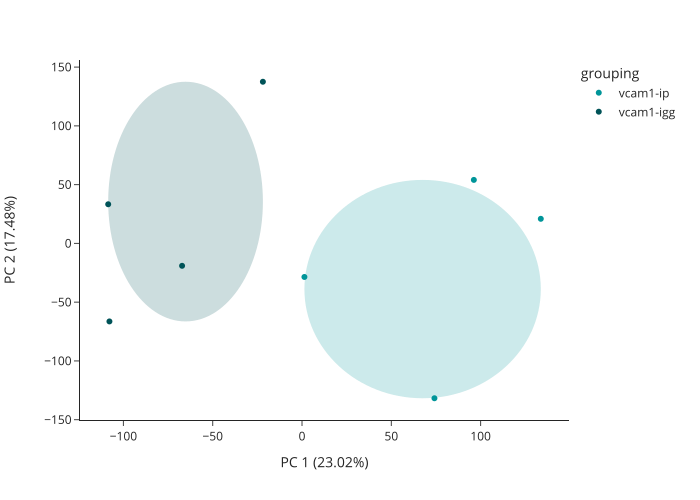

In [7]:
plot = dataset.plot_pca(group = "grouping", circle = True)
plot.show(renderer = "svg")

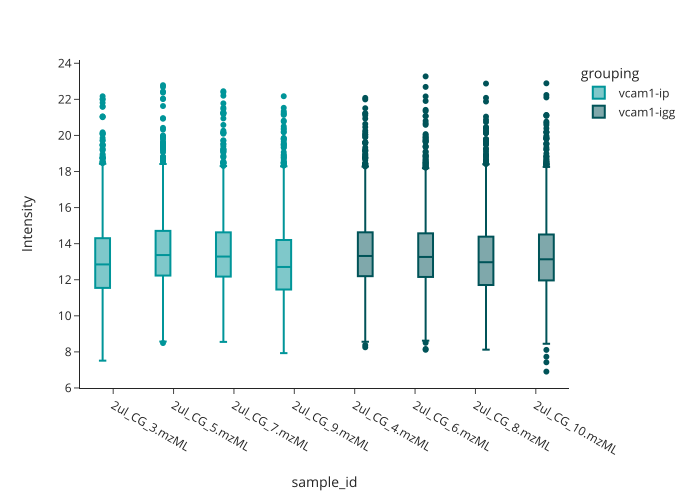

In [8]:
plot = dataset.plot_sampledistribution(color = "grouping", method="box", log_scale=False)
plot.show(renderer = "svg")

In [10]:
df_diff = dataset.diff_expression_analysis(column="grouping",
                                 group1 = "vcam1-ip",
                                 group2 = "vcam1-igg",
                                 method = "ttest"
                                 )
df_sign = df_diff[
    (df_diff["pval"] <= 0.05) &
    (df_diff["log2fc"] >= 1)
]
df_sign.head(20)

,Protein.Group,pval,log2fc
23,A0A0B4J1H7;A0A0B4J1H8,0.000006,2.600554
320,O35449,0.000004,5.227543
362,O54962,0.010806,1.634769
479,P03975,0.000077,3.336940
741,P40630,0.000420,1.158516
848,P55088,0.000002,6.440797
1315,Q3UHJ0,0.000124,1.475810
1481,Q60749,0.001186,2.874323
1949,Q80UW8,0.046003,1.002340
2342,Q8CHG7,0.001116,1.154969


In [ ]:
proteins_to_highlight = ["P29533"]

In [ ]:
plot = dataset.plot_volcano(column = "grouping", 
                            group1 = "vcam1-ip", 
                            group2 = "vcam1-igg", 
                            method = "ttest",
                            color_list = proteins_to_highlight)
plot.show()

In [ ]:
plot = dataset.plot_intensity(protein_id="P29533", group = "grouping", method = "scatter", log_scale=False)
plot.show(renderer = "svg")

# Pedro's DIA-NN run on windows

In [ ]:
pedro_diann_data = alphastats.DIANNLoader(file="/Volumes/KINGSTON/data/phd/ip-proteomics/exp17_vcam1_syn_replicates.pg_matrix.tsv")

In [ ]:
pedro_dataset = alphastats.DataSet(
    loader = pedro_diann_data, 
    metadata_path="pedro_metadata_alphastats.xlsx", 
    sample_column="sample_id"
)

In [ ]:
vcam1_pre_pedro = pedro_dataset.rawinput[pedro_dataset.rawinput["Protein.Group"]=="P29533"]
vcam1_pre_pedro

In [ ]:
pedro_dataset.preprocess(
    log2_transform = True,
    remove_contaminations=False,
    normalization = None,
    imputation = None,
    remove_samples=["2ul_CG_1.wiff", "2ul_CG_2.wiff"]
)

In [ ]:
vcam1_post = pedro_dataset.mat["P29533"]
vcam1_post

In [ ]:
plot = pedro_dataset.plot_pca(group = "grouping", circle = True)
plot.show(renderer = "svg")

In [ ]:
plot = pedro_dataset.plot_sampledistribution(color = "grouping", method="box", log_scale=False)
plot.show(renderer = "svg")

In [ ]:
df_pedro_diff = pedro_dataset.diff_expression_analysis(column="grouping",
                                 group1 = "vcam1-ip",
                                 group2 = "vcam1-igg",
                                 method = "ttest"
                                 )
df_pedro_sign = df_pedro_diff[
    (df_pedro_diff["pval"] <= 0.05) &
    (df_pedro_diff["log2fc"] >= 1)
]
df_pedro_sign.shape

In [ ]:
proteins_to_highlight = ["P29533"]

In [ ]:
plot = dataset.plot_volcano(column = "grouping", 
                            group1 = "vcam1-ip", 
                            group2 = "vcam1-igg", 
                            method = "ttest",
                            color_list = proteins_to_highlight)
plot.show()